In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

file_path = r"C:/Users/Aryan/OneDrive/Desktop/LEAKDB project/data/LeakDB-master/LeakDB-master/CCWI-WDSA2018/Benchmarks/Hanoi_CMH/Scenario-1/Pressures/Node_1.csv"

df = pd.read_csv(file_path)

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

First 5 rows:
             Timestamp  Value
0  2017-01-01 00:00:00    0.0
1  2017-01-01 00:30:00    0.0
2  2017-01-01 01:00:00    0.0
3  2017-01-01 01:30:00    0.0
4  2017-01-01 02:00:00    0.0

Dataset Shape:
(17520, 2)

Column Names:
Index(['Timestamp', 'Value'], dtype='object')


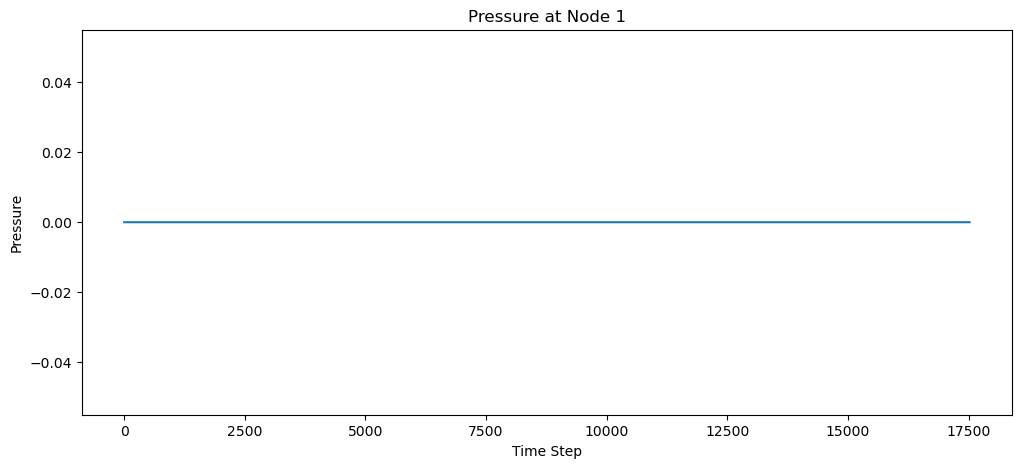

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Value'])

plt.title('Pressure at Node 1')
plt.xlabel('Time Step')
plt.ylabel('Pressure')

plt.show()

In [5]:
print(df['Value'].describe())

count    17520.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: Value, dtype: float64


In [6]:
import pandas as pd

file_path = r"C:/Users/Aryan/OneDrive/Desktop/LEAKDB project/data/LeakDB-master/LeakDB-master/CCWI-WDSA2018/Benchmarks/Hanoi_CMH/Scenario-1/Pressures/Node_10.csv"

df10 = pd.read_csv(file_path)

print(df10.head())
print(df10['Value'].describe())

             Timestamp   Value
0  2017-01-01 00:00:00  67.015
1  2017-01-01 00:30:00  67.738
2  2017-01-01 01:00:00  68.139
3  2017-01-01 01:30:00  68.456
4  2017-01-01 02:00:00  68.703
count    17520.000000
mean        61.855165
std          4.191391
min         46.651000
25%         59.012000
50%         61.580000
75%         65.531250
max         68.840000
Name: Value, dtype: float64


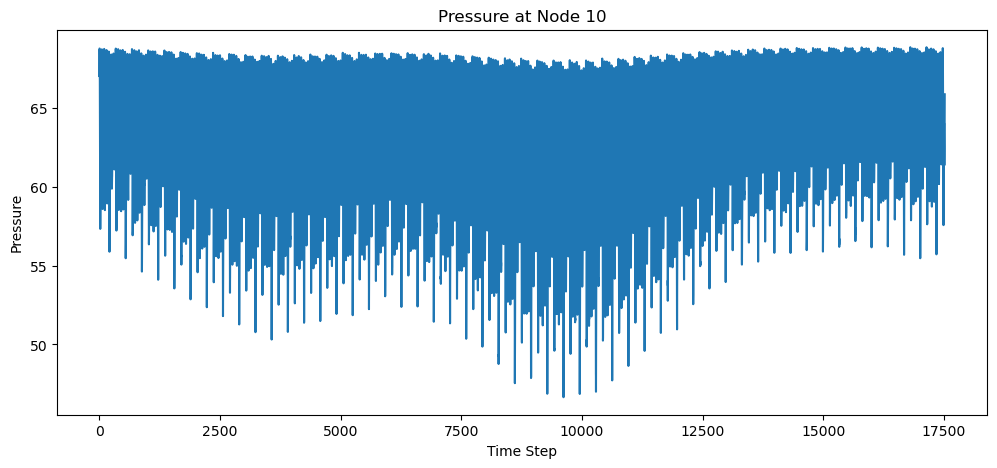

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df10['Value'])
plt.title("Pressure at Node 10")
plt.xlabel("Time Step")
plt.ylabel("Pressure")
plt.show()

In [8]:
labels_path = r"C:/Users/Aryan/OneDrive/Desktop/LEAKDB project/data/LeakDB-master/LeakDB-master/CCWI-WDSA2018/Benchmarks/Hanoi_CMH/Scenario-1/Labels.csv"

labels = pd.read_csv(labels_path)

print(labels.head())
print(labels.shape)

             Timestamp  Label
0  2017-01-01 00:00:00    0.0
1  2017-01-01 00:30:00    0.0
2  2017-01-01 01:00:00    0.0
3  2017-01-01 01:30:00    0.0
4  2017-01-01 02:00:00    0.0
(17520, 2)


In [9]:
print(labels['Label'].value_counts())

Label
0.0    17520
Name: count, dtype: int64


In [10]:
print("Leak Percentage:",
      100*labels['Label'].sum()/len(labels),
      "%")

Leak Percentage: 0.0 %


In [11]:
labels[labels['Label']==1].head()

,Timestamp,Label


In [12]:
labels['Label'].unique()

array([0.])

In [13]:
labels2_path = r"C:\/Users/Aryan/OneDrive/Desktop/LEAKDB project/data/LeakDB-master/LeakDB-master/CCWI-WDSA2018/Benchmarks/Hanoi_CMH/Scenario-2/Labels.csv"

labels2 = pd.read_csv(labels2_path)

print(labels2['Label'].value_counts())
print(labels2['Label'].unique())

Label
0.0    17520
Name: count, dtype: int64
[0.]


In [14]:
import pandas as pd

base_path = r"C:\Users\Aryan\OneDrive\Desktop\LEAKDB project\data\LeakDB-master\LeakDB-master\CCWI-WDSA2018\Benchmarks\Hanoi_CMH"

for i in range(1,11):
    path = f"{base_path}\\Scenario-{i}\\Labels.csv"

    labels = pd.read_csv(path)

    leak_count = labels['Label'].sum()

    print(f"Scenario-{i}: {int(leak_count)} leak records")

Scenario-1: 0 leak records
Scenario-2: 0 leak records
Scenario-3: 6527 leak records
Scenario-4: 0 leak records
Scenario-5: 5930 leak records
Scenario-6: 1677 leak records
Scenario-7: 316 leak records
Scenario-8: 4937 leak records
Scenario-9: 0 leak records
Scenario-10: 7704 leak records


In [15]:
pressure_path = r"C:/Users/Aryan/OneDrive/Desktop/LEAKDB project/data/LeakDB-master/LeakDB-master/CCWI-WDSA2018/Benchmarks/Hanoi_CMH/Scenario-10/Pressures/Node_10.csv"

label_path = r"C:/Users/Aryan/OneDrive/Desktop/LEAKDB project/data/LeakDB-master/LeakDB-master/CCWI-WDSA2018/Benchmarks/Hanoi_CMH/Scenario-10/Labels.csv"

pressure = pd.read_csv(pressure_path)
labels = pd.read_csv(label_path)

data = pd.DataFrame({
    'Pressure': pressure['Value'],
    'Leak': labels['Label']
})

print(data.head())
print("\nShape:", data.shape)

   Pressure  Leak
0    68.037   0.0
1    68.393   0.0
2    68.710   0.0
3    68.911   0.0
4    69.047   0.0

Shape: (17520, 2)


In [16]:
print(data['Leak'].value_counts())

Leak
0.0    9816
1.0    7704
Name: count, dtype: int64


In [17]:
print(data.groupby('Leak')['Pressure'].describe())

       count       mean       std     min      25%     50%       75%     max
Leak                                                                        
0.0   9816.0  65.165574  2.322837  57.994  63.5030  64.907  67.21700  69.155
1.0   7704.0  62.102290  3.461128  48.013  59.9435  61.852  64.92125  68.081


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Features and target
X = data[['Pressure']]
y = data['Leak']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Results
print("Accuracy =", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy = 0.7014840182648402

Classification Report:
              precision    recall  f1-score   support

         0.0       0.73      0.74      0.73      1951
         1.0       0.67      0.66      0.66      1553

    accuracy                           0.70      3504
   macro avg       0.70      0.70      0.70      3504
weighted avg       0.70      0.70      0.70      3504



In [19]:
pwd

'C:\\Users\\Aryan'